# Imports

In [18]:
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# from scipy.interpolate import RegularGridInterpolator
# from scipy.interpolate import interp1d

import aespm as ae


In [133]:
# connection, client = return_connection(host, username, password)

# Read the scan line

folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260619\PZTO"

exp = ae.Experiment(folder=folder)


In [134]:
## Commonly used custom functions

def load_ibw(self, folder="C:\\Users\\Asylum User\\Documents\\AEtesting\\data_exchange", lines=False):
    '''
    Read the latest ibw file saved in a given folder.
    '''
    fname = ae.get_files(path=self.folder, client=self.client)[0]
    return ae.tools.load_ibw(fname)

exp.add_func(load_ibw)

def read_meter(self):
    ae.write_spm(commands="GetMeter()", connection=self.connection)
    w = ae.ibw_read(r"C:\Users\Asylum User\Documents\buffer\Meter.ibw", lines=True, connection=self.connection)
    return w

exp.add_func(read_meter)

# def ramp_drive_setpoint(self, drive, setpoint):
#     commands='SetDriveAmpAndSetpoint({}, {})'.format(drive, setpoint)
#     ae.write_spm(commands=commands, connection=self.connection)
    
# exp.add_func(ramp_drive_setpoint)

def check_files(self, wait=360):
    '''
    Check the number of files in the folder, with 50 s max waiting time.
    '''
    return ae.check_file_number(path=self.folder, retry=int(wait/0.1))
exp.add_func(check_files)

# Swtich to LDART 

In [4]:
img_v = exp.load_ibw(folder=exp.folder)

In [6]:
ae.write_spm('XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")')


In [7]:
ae.write_spm('XPTButtonFunc("WriteXPT")')


In [8]:
ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 1)')

In [10]:
ae.tune_probe(num=2, center=650e3, width=100e3)

In [11]:
exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

KeyboardInterrupt: 

In [12]:
img_l = exp.load_ibw(folder=exp.folder)

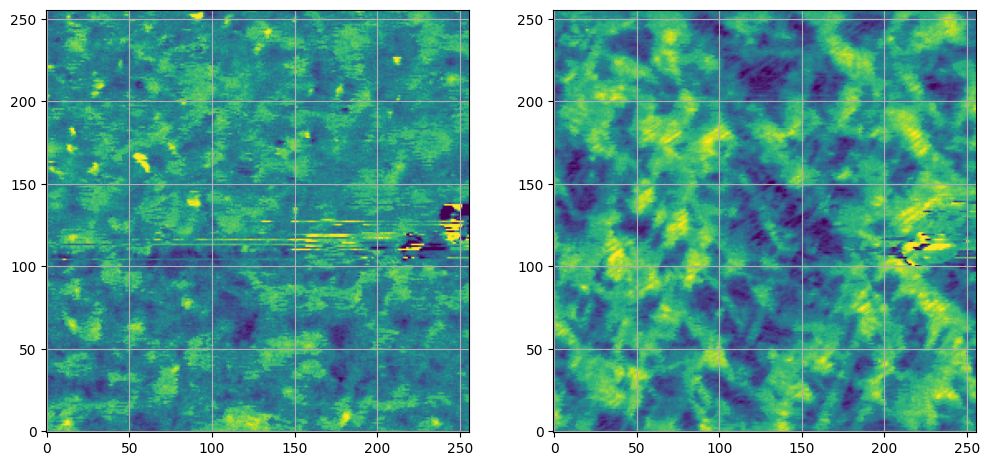

In [17]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * np.cos(img_v.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

ax[0].imshow(tp1, clim=[c-3*s, c+3*s], origin='lower')
ax[1].imshow(img_l.data[2] * np.cos(img_l.data[4] / 180 * np.pi), clim=[c-5*s, c+5*s], origin='lower')

ax[0].grid()
ax[1].grid()

# Switch back to VDART

In [42]:
ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')

In [43]:
ae.tune_probe(num=4, center=350e3, width=100e3)

In [44]:
# exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

True

In [45]:
img_v = exp.load_ibw(folder=exp.folder)

In [46]:
cmd = 'XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n\
XPTButtonFunc("WriteXPT")\n\
XPTBoxFunc("DontChangeXPTCheck", 1)'

ae.write_spm(cmd)

In [47]:
ae.tune_probe(num=4, center=650e3, width=100e3)

In [48]:
exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

True

In [49]:
img_l = exp.load_ibw(folder=exp.folder)

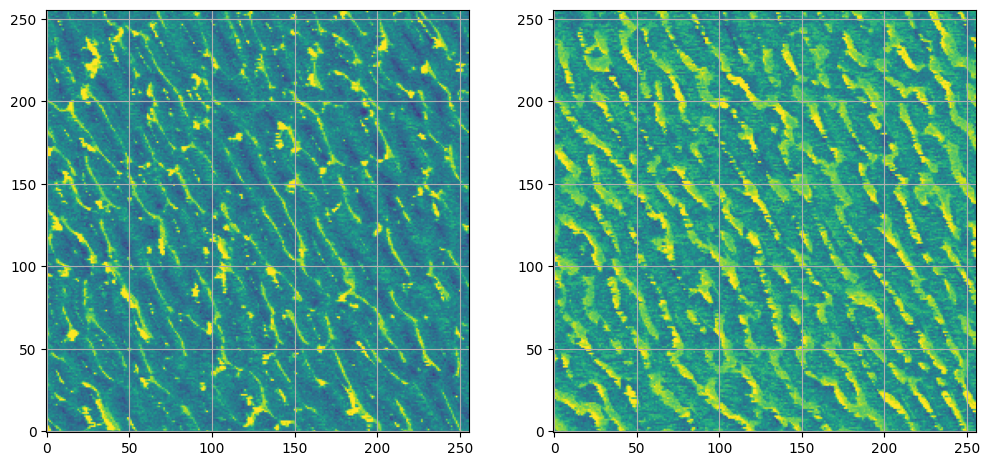

In [51]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * np.cos(img_v.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

ax[0].imshow(tp1, clim=[c-3*s, c+3*s], origin='lower')
ax[1].imshow(img_l.data[2] * np.cos(img_l.data[4] / 180 * np.pi), clim=[c-3*s, c+3*s], origin='lower')

ax[0].grid()
ax[1].grid()

# Trajectory based domain writing

## Pole the domains

In [57]:
HAVE_AESPM  = True
import json

CONFIG = dict(
    # --- paths -----------------------------------------------------------
    data_folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260612\PZTO-111",
    work_dir    = "output",      # trajectories + logs live here

    # --- microscope / litho ------------------------------------------------
    DRY_RUN       = False,    # False at the microscope
    field_um      = 2.0,     # litho field size (square, corner origin)
    write_speed_ums = 1.0,   # tip speed during litho
    step_um       = 0.02,    # point spacing along trajectory (sets dose uniformity)
    travel_v      = 0.0,     # bias during repositioning strokes
    litho_margin_s = 10.0,   # extra wait after estimated litho duration

    # --- PFM readout ---------------------------------------------------------
    chan_height = 0, chan_amp = 1, chan_phase = 3,   # ibw channel indices (as in v1)
    scan_px     = 256,

    # --- material: PZTO(111), three easy axes at 120 deg --------------------
    # axis0_offset_deg is the lab-frame angle of the first easy axis;
    # you will refine it from the pristine stripe orientations / Session A.
    axis0_offset_deg = 0.0,
    n_variants  = 6,
    easy_axes_deg = None,    # filled below

    # --- switching physics (seed values; Session A refines) -----------------
    v_coercive_guess = 4.0,  # |V| onset (Checa: 4-6 V in PSTO; measure yours)
    v_write          = 6.0,
    # bias sign convention: +1 if positive tip bias selects the variant
    # PARALLEL to tip motion, -1 if anti-parallel (Balke-style). Session A decides.
    bias_sign_convention = -1,
    linewidth_um_guess   = 0.12,   # written track width (from first line tests)
)
CONFIG["easy_axes_deg"] = [CONFIG["axis0_offset_deg"] + k*60 for k in range(6)]
os.makedirs(CONFIG["work_dir"], exist_ok=True)
if not HAVE_AESPM:
    CONFIG["DRY_RUN"] = True
print(json.dumps({k: v for k, v in CONFIG.items() if k != "easy_axes_deg"}, indent=1))
print("easy axes:", CONFIG["easy_axes_deg"])

{
 "data_folder": "C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260612\\PZTO-111",
 "work_dir": "output",
 "DRY_RUN": false,
 "field_um": 2.0,
 "write_speed_ums": 1.0,
 "step_um": 0.02,
 "travel_v": 0.0,
 "litho_margin_s": 10.0,
 "chan_height": 0,
 "chan_amp": 1,
 "chan_phase": 3,
 "scan_px": 256,
 "axis0_offset_deg": 0.0,
 "n_variants": 6,
 "v_coercive_guess": 4.0,
 "v_write": 6.0,
 "bias_sign_convention": -1,
 "linewidth_um_guess": 0.12
}
easy axes: [0.0, 60.0, 120.0, 180.0, 240.0, 300.0]


In [54]:
def generate_spiral_trajectory(
    turns=6,
    n_points=1200,
    k=1.0,
    offset=0.0,
    v_amplitude=8.0,
    v_offset=0.0,
    field_um=20.0,
    max_radius_um=None,
    filename="spiral_trajectory.txt",
    include_header=True,
    plot=True,
    constant_v=False
):
    """
    Build an Archimedean-spiral (x, y, V) trajectory and save it as a 3-column
    text file for the Igor TrajectoryLitho panel.

    Coordinates are written in METRES, corner origin (0..field), spiral centred
    at (field/2, field/2).  Voltage:  v_amplitude*sin(k*theta + offset) + v_offset.

    Parameters
    ----------
    turns         : full revolutions of the spiral.
    n_points      : number of points along the path.
    k             : angular-frequency multiplier inside the sine.
    offset        : phase offset (radians) inside the sine.
    v_amplitude   : sinusoid amplitude (V).
    v_offset      : DC offset added to the bias (V).
    field_um      : square litho field size in micrometres.
    max_radius_um : outer spiral radius (um). Default 0.95*field/2; must be <= field/2.
    filename      : output .txt path.
    include_header: write a commented header row.
    plot          : show an inline preview.

    Returns
    -------
    (x_m, y_m, v) numpy arrays.
    """
    field_m = field_um * 1e-6
    cx = cy = field_m / 2.0

    if max_radius_um is None:
        max_radius_m = 0.95 * field_m / 2.0
    else:
        max_radius_m = max_radius_um * 1e-6
        if max_radius_m > field_m / 2.0:
            raise ValueError(
                f"max_radius_um ({max_radius_um}) exceeds half the field "
                f"({field_um/2}); the spiral would fall outside the field."
            )

    theta = np.linspace(0.0, turns * 2.0 * np.pi, n_points)
    theta_max = turns * 2.0 * np.pi
    a = max_radius_m / theta_max if theta_max > 0 else 0.0
    r = a * theta

    x_m = cx + r * np.cos(theta)
    y_m = cy + r * np.sin(theta)
    if constant_v:
        v = v_amplitude * np.ones(len(theta))
    else:
        
        v   = v_amplitude * np.sin(k * theta + offset) + v_offset

    data = np.column_stack([x_m, y_m, v])
    header = "X_m\tY_m\tV" if include_header else ""
    np.savetxt(filename, data, delimiter="\t",
               header=header, comments="# ", fmt="%.10g")

    print(f"Wrote {n_points} points to '{filename}'")
    print(f"  field = {field_um} um, center = ({field_um/2}, {field_um/2}) um")
    print(f"  outer radius = {max_radius_m*1e6:.3f} um, turns = {turns}")
    print(f"  X range: [{x_m.min()*1e6:.3f}, {x_m.max()*1e6:.3f}] um")
    print(f"  Y range: [{y_m.min()*1e6:.3f}, {y_m.max()*1e6:.3f}] um")
    print(f"  V = {v_amplitude}*sin({k}*theta + {offset}) + {v_offset}")
    print(f"  V range: [{v.min():.3f}, {v.max():.3f}] V")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
        sc = ax1.scatter(x_m*1e6, y_m*1e6, c=v, cmap="rainbow", s=6)
        ax1.add_patch(plt.Rectangle((0, 0), field_um, field_um,
                                    fill=False, ls="--", ec="k"))
        ax1.set_aspect("equal")
        ax1.set_xlabel("X (um)"); ax1.set_ylabel("Y (um)")
        ax1.set_title("Spiral trajectory (color = bias)")
        fig.colorbar(sc, ax=ax1, label="Bias (V)")

        ax2.plot(theta, v, lw=1)
        ax2.set_xlabel("theta (rad)"); ax2.set_ylabel("Bias (V)")
        ax2.set_title(f"V = {v_amplitude} sin({k} theta + {offset}) + {v_offset}")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return x_m, y_m, v

def visualize_trajectory(tb=None, x_m=None, y_m=None, v=None, *, filename=None,
                         field_um=None, title=None):
    """Same as v1, plus accepts a TrajectoryBuilder directly."""
    if tb is not None:
        x, y, v = tb.to_arrays(); x_m, y_m = x*1e-6, y*1e-6
        field_um = field_um or tb.field_um
    if filename is not None:
        d = np.loadtxt(filename); x_m, y_m, v = d[:,0], d[:,1], d[:,2]
        title = title or f"Trajectory from '{filename}'"
    x_um, y_um, v = np.asarray(x_m)*1e6, np.asarray(y_m)*1e6, np.asarray(v)
    finite = np.isfinite(x_um) & np.isfinite(y_um); idx = np.arange(len(x_um))
    fig = plt.figure(figsize=(13, 5.5)); gs = fig.add_gridspec(2,2,width_ratios=[1.3,1])
    ax0 = fig.add_subplot(gs[:,0])
    sc = ax0.scatter(x_um[finite], y_um[finite], c=v[finite], cmap="rainbow", s=6, zorder=3)
    ax0.plot(x_um, y_um, color="0.8", lw=.5, zorder=1)
    f = idx[finite]
    if len(f):
        ax0.scatter([x_um[f[0]]],[y_um[f[0]]],s=120,marker="o",facecolors="none",
                    edgecolors="g",lw=2,zorder=4,label="start")
        ax0.scatter([x_um[f[-1]]],[y_um[f[-1]]],s=120,marker="s",facecolors="none",
                    edgecolors="r",lw=2,zorder=4,label="end")
    fu = field_um or CONFIG["field_um"]
    ax0.add_patch(plt.Rectangle((0,0), fu, fu, fill=False, ls="--", ec="k"))
    ax0.set_aspect("equal"); ax0.set_xlabel("X (um)"); ax0.set_ylabel("Y (um)")
    ax0.set_title(title or "Trajectory (color = bias)"); ax0.legend(fontsize=8)
    fig.colorbar(sc, ax=ax0, label="Bias (V)", fraction=.046, pad=.04)
    ax1 = fig.add_subplot(gs[0,1]); ax1.plot(idx, v, lw=1)
    ax1.set_xlabel("point index"); ax1.set_ylabel("Bias (V)"); ax1.grid(alpha=.3)
    ax2 = fig.add_subplot(gs[1,1])
    step = np.hypot(np.diff(x_um), np.diff(y_um))
    ax2.plot(step, lw=1, color="C1"); ax2.set_xlabel("point index")
    ax2.set_ylabel("step (um)"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    
# ----------------------------------------------------------------------
# Low-level helpers
# ----------------------------------------------------------------------
def resample_constant_step(x_um, y_um, v, step_um):
    """Resample a polyline to constant arc-length step.

    The TL panel steps through points at a fixed rate, so constant point
    spacing => constant tip speed and constant bias dose per unit length.
    """
    x_um, y_um, v = map(np.asarray, (x_um, y_um, v))
    d = np.hypot(np.diff(x_um), np.diff(y_um))
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] == 0:
        return x_um[:1], y_um[:1], np.atleast_1d(v)[:1]
    n = max(2, int(np.ceil(s[-1] / step_um)) + 1)
    si = np.linspace(0, s[-1], n)
    return (np.interp(si, s, x_um), np.interp(si, s, y_um),
            np.interp(si, s, np.broadcast_to(v, x_um.shape)))


class TrajectoryBuilder:
    """Accumulate biased strokes; insert zero-bias travel moves between them.

    All coordinates in micrometres, corner origin (0..field_um), matching the
    convention of generate_spiral_trajectory in the original notebook.
    """

    def __init__(self, field_um=20.0, step_um=0.02, travel_v=0.0,
                 nan_breaks=False):
        self.field_um = field_um
        self.step_um = step_um
        self.travel_v = travel_v   # bias during repositioning (keep 0!)
        self.nan_breaks = nan_breaks  # PLACEHOLDER: only if TL supports NaN pen-up
        self._segs = []            # list of (x_um, y_um, v) arrays

    def stroke(self, pts_um, v):
        """Add a biased stroke. pts_um: (N,2) array; v: scalar or (N,) array."""
        pts_um = np.asarray(pts_um, float)
        x, y = pts_um[:, 0], pts_um[:, 1]
        x, y, vv = resample_constant_step(x, y, v, self.step_um)
        self._segs.append((x, y, vv))
        return self

    def to_arrays(self):
        """Concatenate strokes, inserting travel moves at travel_v."""
        xs, ys, vs = [], [], []
        for i, (x, y, v) in enumerate(self._segs):
            if i > 0:
                if self.nan_breaks:
                    xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
                else:
                    x0, y0 = xs[-1][-1], ys[-1][-1]
                    tx, ty, tv = resample_constant_step(
                        [x0, x[0]], [y0, y[0]], self.travel_v, self.step_um)
                    xs.append(tx); ys.append(ty); vs.append(tv)
            xs.append(x); ys.append(y); vs.append(v)
        return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))

    def save(self, filename, include_header=True):
        x_um, y_um, v = self.to_arrays()
        data = np.column_stack([x_um * 1e-6, y_um * 1e-6, v])
        header = "X_m\tY_m\tV" if include_header else ""
        np.savetxt(filename, data, delimiter="\t", header=header,
                   comments="# ", fmt="%.10g")
        finite = np.isfinite(x_um)
        d = np.hypot(np.diff(x_um[finite]), np.diff(y_um[finite]))
        print(f"Wrote {len(x_um)} pts to '{filename}'  "
              f"(path length {np.nansum(d):.1f} um, "
              f"{len(self._segs)} strokes)")
        return x_um * 1e-6, y_um * 1e-6, v

    def path_length_um(self):
        x, y, _ = self.to_arrays()
        m = np.isfinite(x)
        return float(np.nansum(np.hypot(np.diff(x[m]), np.diff(y[m]))))

In [55]:
def gen_diameter_scan(n_lines=6, radius_um=0.8, center_um=(1.0, 1.0), v=-5.5,
                      start_angle_deg=0.0, signed_pass_bias=True,
                      field_um=2.0, step_um=0.01, tb=None, pts_per_line=400):
    """Diameter-scan poling pattern.

    Each line is a full DIAMETER: from one edge, through the center, to the opposite
    edge. The line is written twice -- forward (edge A -> edge B) at -|v| and back
    (edge B -> edge A) at +|v| -- then the angle advances to the next diameter.
    Because a diameter at theta and theta+180 deg are the same line, the angles span
    only [0, 180) deg: n_lines diameters at 0, 180/n, 2*180/n, ...

    n_lines           : number of distinct diameter orientations (over 180 deg)
    radius_um         : half-length of each diameter (diameter length = 2*radius_um)
    center_um         : (cx, cy) center of the pattern
    v                 : pulse magnitude; sign is set per-pass (see signed_pass_bias).
                        Its absolute value is what matters; the forward pass uses
                        -|v|, the return pass +|v|.
    start_angle_deg   : rotates the whole pattern (align to easy axes)
    signed_pass_bias  : True  -> forward pass at -|v|, return pass at +|v|
                        False -> both passes at v (no sign flip)
    pts_per_line      : samples along one diameter traversal (one direction)
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um)
    cx, cy = center_um
    R = radius_um
    vmag = abs(v)

    # diameter orientations over 180 deg only (theta and theta+180 are the same line)
    angles = np.deg2rad(start_angle_deg) + np.linspace(0, np.pi, n_lines, endpoint=False)

    for phi in angles:
        ux, uy = np.cos(phi), np.sin(phi)          # unit vector along this diameter

        # parametrize from -R (edge A) to +R (edge B)
        t = np.linspace(-R, R, pts_per_line, endpoint=True)
        xf = cx + t * ux
        yf = cy + t * uy

        # forward pass: edge A -> edge B at -|v|
        v_fwd = (-vmag if signed_pass_bias else v)
        tb.stroke(np.column_stack([xf, yf]), np.full(pts_per_line, v_fwd, float))

        # return pass: edge B -> edge A at +|v|  (reverse the same points)
        v_ret = (+vmag if signed_pass_bias else v)
        tb.stroke(np.column_stack([xf[::-1], yf[::-1]]), np.full(pts_per_line, v_ret, float))

    return tb

Wrote 13291 pts to 'output\rose_flower_N64_1um.txt'  (path length 259.1 um, 128 strokes)


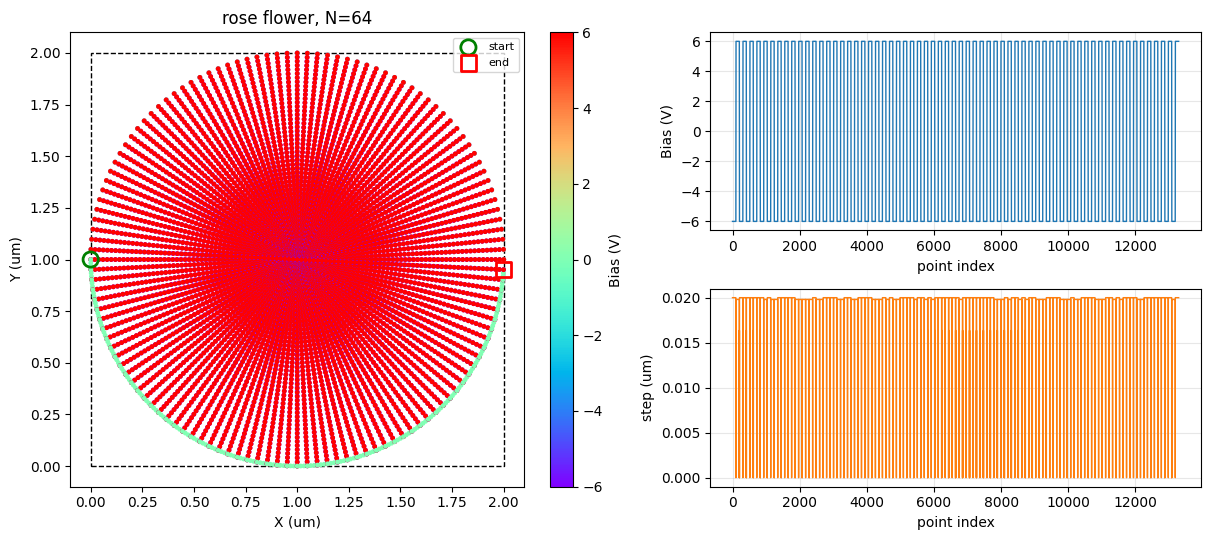

In [189]:
# example: 6-leaf flower in your 2 um frame

tb = gen_diameter_scan(n_lines=64, radius_um=1, center_um=(1, 1), v=-6, field_um=1, step_um=0.02, pts_per_line=100)
fname = os.path.join(CONFIG["work_dir"], "rose_flower_N64_1um.txt")
tb.save(fname)

# tb.save(os.path.join(CONFIG["work_dir"], "rose_flower_N6_2um.txt"))
visualize_trajectory(tb=tb, field_um=2, title="rose flower, N=64")

In [191]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
#ae.write_spm(commands='TL_ToggleOverlay()')

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\rose_flower_N64_1um.txt")


In [162]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')      # live scan center, 0.5 um/s

In [190]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

## Read out the results

In [186]:
ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')

ae.tune_probe(num=4, center=350e3, width=100e3)

In [187]:
exp.execute('ChangeName', "PZTO_VDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

img_v = exp.load_ibw(folder=exp.folder)

In [124]:
# img_v = exp.load_ibw(folder=exp.folder)

In [192]:
cmd = 'XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n\
XPTButtonFunc("WriteXPT")\n\
XPTBoxFunc("DontChangeXPTCheck", 1)'

ae.write_spm(cmd)

time.sleep(2)

In [193]:
ae.tune_probe(num=4, center=650e3, width=100e3)

In [194]:
exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

img_l = exp.load_ibw(folder=exp.folder)

In [200]:
img_v = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260619\PZTO\PZTO_VDART_0004.ibw")

img_l = ae.tools.load_ibw(r"C:\Users\Asylum User\Documents\Asylum Research Data\260619\PZTO\PZTO_LDART_0004.ibw")

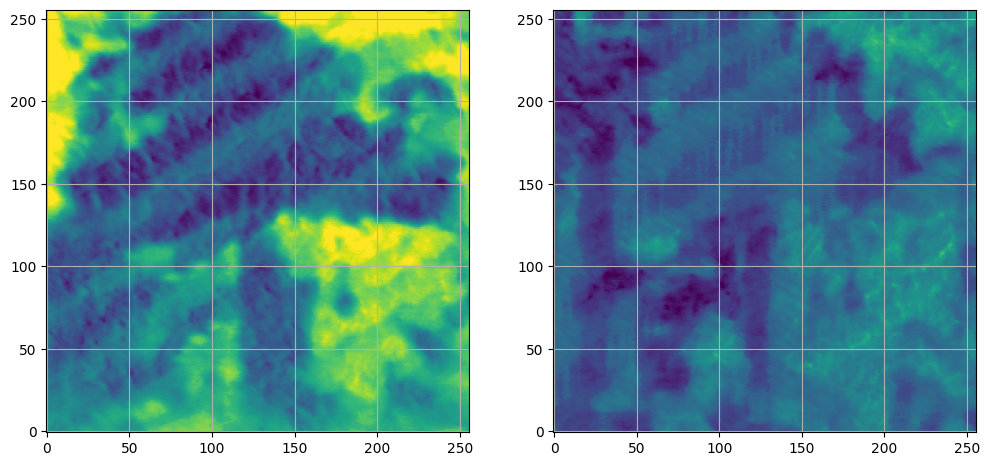

In [210]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[2] * np.cos(img_v.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

ax[0].imshow(tp1, clim=[c-2/1*s, c+2/1*s], origin='lower', )
im = ax[1].imshow(img_l.data[2] * np.cos(img_l.data[4] / 180 * np.pi), clim=[c-.5/1*s, c+4/1*s], origin='lower', )

# plt.colorbar(im, ax=ax[1])
ax[0].grid()
ax[1].grid()

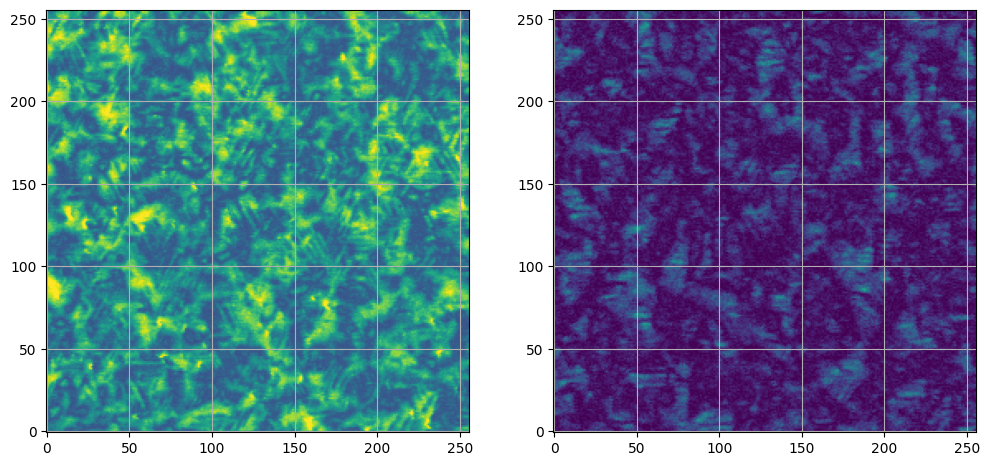

In [198]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
tp1 = img_v.data[1] * 1 #np.cos(img_v.data[4] / 180 * np.pi)
tp2 = img_l.data[1] * 1 #np.cos(img_l.data[4] / 180 * np.pi)
c = np.mean(tp1)
s = np.std(tp1)

ax[0].imshow(tp1, clim=[c-3/1*s, c+3/1*s], origin='lower', )
im = ax[1].imshow(tp2, clim=[c-3/2*s, c+3/2*s], origin='lower', )

# plt.colorbar(im, ax=ax[1])
ax[0].grid()
ax[1].grid()

# Spiral scans

In [143]:
def generate_spiral_trajectory(
    turns=6,
    n_points=1200,
    k=1.0,
    offset=0.0,
    v_amplitude=8.0,
    v_offset=0.0,
    field_um=20.0,
    max_radius_um=None,
    filename="spiral_trajectory.txt",
    include_header=True,
    plot=True,
    constant_v=False
):
    """
    Build an Archimedean-spiral (x, y, V) trajectory and save it as a 3-column
    text file for the Igor TrajectoryLitho panel.

    Coordinates are written in METRES, corner origin (0..field), spiral centred
    at (field/2, field/2).  Voltage:  v_amplitude*sin(k*theta + offset) + v_offset.

    Parameters
    ----------
    turns         : full revolutions of the spiral.
    n_points      : number of points along the path.
    k             : angular-frequency multiplier inside the sine.
    offset        : phase offset (radians) inside the sine.
    v_amplitude   : sinusoid amplitude (V).
    v_offset      : DC offset added to the bias (V).
    field_um      : square litho field size in micrometres.
    max_radius_um : outer spiral radius (um). Default 0.95*field/2; must be <= field/2.
    filename      : output .txt path.
    include_header: write a commented header row.
    plot          : show an inline preview.

    Returns
    -------
    (x_m, y_m, v) numpy arrays.
    """
    field_m = field_um * 1e-6
    cx = cy = field_m / 2.0

    if max_radius_um is None:
        max_radius_m = 0.95 * field_m / 2.0
    else:
        max_radius_m = max_radius_um * 1e-6
        if max_radius_m > field_m / 2.0:
            raise ValueError(
                f"max_radius_um ({max_radius_um}) exceeds half the field "
                f"({field_um/2}); the spiral would fall outside the field."
            )

    theta = np.linspace(0.0, turns * 2.0 * np.pi, n_points)
    theta_max = turns * 2.0 * np.pi
    a = max_radius_m / theta_max if theta_max > 0 else 0.0
    r = a * theta

    x_m = cx + r * np.cos(theta)
    y_m = cy + r * np.sin(theta)
    if constant_v:
        v = v_amplitude * np.ones(len(theta))
    else:
        
        v   = v_amplitude * np.sin(k * theta + offset) + v_offset

    data = np.column_stack([x_m, y_m, v])
    header = "X_m\tY_m\tV" if include_header else ""
    np.savetxt(filename, data, delimiter="\t",
               header=header, comments="# ", fmt="%.10g")

    print(f"Wrote {n_points} points to '{filename}'")
    print(f"  field = {field_um} um, center = ({field_um/2}, {field_um/2}) um")
    print(f"  outer radius = {max_radius_m*1e6:.3f} um, turns = {turns}")
    print(f"  X range: [{x_m.min()*1e6:.3f}, {x_m.max()*1e6:.3f}] um")
    print(f"  Y range: [{y_m.min()*1e6:.3f}, {y_m.max()*1e6:.3f}] um")
    print(f"  V = {v_amplitude}*sin({k}*theta + {offset}) + {v_offset}")
    print(f"  V range: [{v.min():.3f}, {v.max():.3f}] V")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
        sc = ax1.scatter(x_m*1e6, y_m*1e6, c=v, cmap="rainbow", s=6)
        ax1.add_patch(plt.Rectangle((0, 0), field_um, field_um,
                                    fill=False, ls="--", ec="k"))
        ax1.set_aspect("equal")
        ax1.set_xlabel("X (um)"); ax1.set_ylabel("Y (um)")
        ax1.set_title("Spiral trajectory (color = bias)")
        fig.colorbar(sc, ax=ax1, label="Bias (V)")

        ax2.plot(theta, v, lw=1)
        ax2.set_xlabel("theta (rad)"); ax2.set_ylabel("Bias (V)")
        ax2.set_title(f"V = {v_amplitude} sin({k} theta + {offset}) + {v_offset}")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return x_m, y_m, v

def visualize_trajectory(tb=None, x_m=None, y_m=None, v=None, *, filename=None,
                         field_um=None, title=None):
    """Same as v1, plus accepts a TrajectoryBuilder directly."""
    if tb is not None:
        x, y, v = tb.to_arrays(); x_m, y_m = x*1e-6, y*1e-6
        field_um = field_um or tb.field_um
    if filename is not None:
        d = np.loadtxt(filename); x_m, y_m, v = d[:,0], d[:,1], d[:,2]
        title = title or f"Trajectory from '{filename}'"
    x_um, y_um, v = np.asarray(x_m)*1e6, np.asarray(y_m)*1e6, np.asarray(v)
    finite = np.isfinite(x_um) & np.isfinite(y_um); idx = np.arange(len(x_um))
    fig = plt.figure(figsize=(13, 5.5)); gs = fig.add_gridspec(2,2,width_ratios=[1.3,1])
    ax0 = fig.add_subplot(gs[:,0])
    sc = ax0.scatter(x_um[finite], y_um[finite], c=v[finite], cmap="rainbow", s=6, zorder=3)
    ax0.plot(x_um, y_um, color="0.8", lw=.5, zorder=1)
    f = idx[finite]
    if len(f):
        ax0.scatter([x_um[f[0]]],[y_um[f[0]]],s=120,marker="o",facecolors="none",
                    edgecolors="g",lw=2,zorder=4,label="start")
        ax0.scatter([x_um[f[-1]]],[y_um[f[-1]]],s=120,marker="s",facecolors="none",
                    edgecolors="r",lw=2,zorder=4,label="end")
    fu = field_um or CONFIG["field_um"]
    ax0.add_patch(plt.Rectangle((0,0), fu, fu, fill=False, ls="--", ec="k"))
    ax0.set_aspect("equal"); ax0.set_xlabel("X (um)"); ax0.set_ylabel("Y (um)")
    ax0.set_title(title or "Trajectory (color = bias)"); ax0.legend(fontsize=8)
    fig.colorbar(sc, ax=ax0, label="Bias (V)", fraction=.046, pad=.04)
    ax1 = fig.add_subplot(gs[0,1]); ax1.plot(idx, v, lw=1)
    ax1.set_xlabel("point index"); ax1.set_ylabel("Bias (V)"); ax1.grid(alpha=.3)
    ax2 = fig.add_subplot(gs[1,1])
    step = np.hypot(np.diff(x_um), np.diff(y_um))
    ax2.plot(step, lw=1, color="C1"); ax2.set_xlabel("point index")
    ax2.set_ylabel("step (um)"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    

Wrote 16384 points to 'spiral_live.txt'
  field = 2.0 um, center = (1.0, 1.0) um
  outer radius = 0.950 um, turns = 40
  X range: [0.062, 1.950] um
  Y range: [0.056, 1.932] um
  V = -6.0*sin(3.0*theta + 0) + 0.0
  V range: [-6.000, -6.000] V


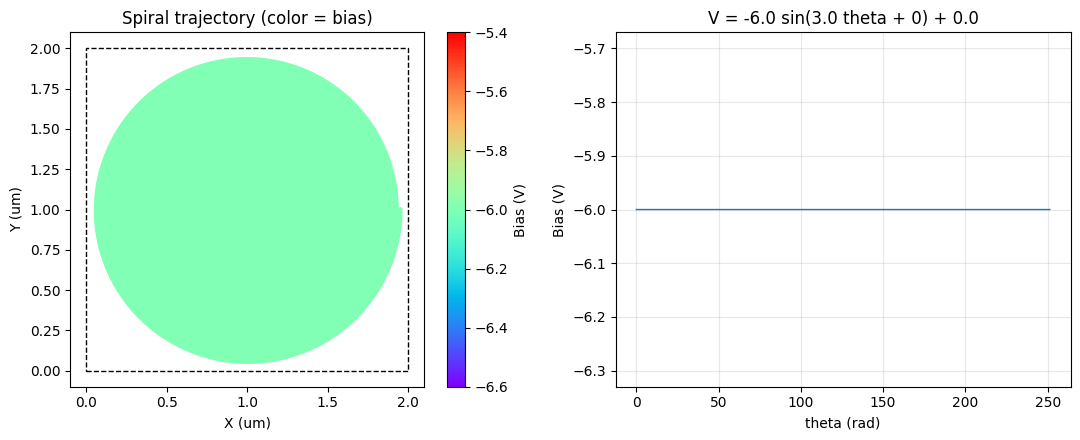

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\spiral_live.txt")


In [144]:
import os
fname = "spiral_live.txt"
generate_spiral_trajectory(
    turns=40, n_points=128**2, k=3.0, offset=0,
    v_amplitude=-6.0, v_offset=0.0, field_um=2.,
    filename=fname,
    constant_v=True
)

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)

In [145]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

# Squares

Wrote 14272 pts to 'output\quadrant_raster_2um.txt'  (path length 138.0 um, 172 strokes)


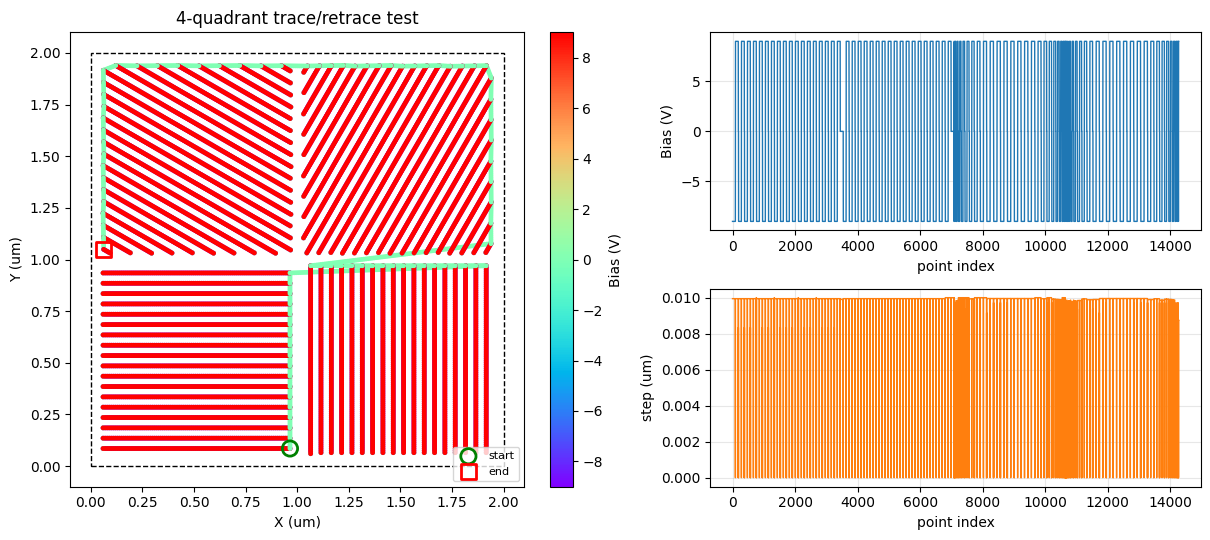

In [177]:
def gen_quadrant_raster(tb, rect, retrace_angle_deg, pitch_um, v_write,
                        samp_um=0.005, constant_bias=False):
    """Serpentine fill: every line traced at 0 V against the named direction,
    then retraced at v_write ALONG it. rect = (x0, x1, y0, y1) in um."""
    x0, x1, y0, y1 = rect
    a = np.deg2rad(retrace_angle_deg)
    u = np.array([np.cos(a), np.sin(a)])          # biased (retrace) direction
    n = np.array([-u[1], u[0]])                   # line-stepping direction
    corners = np.array([[x0,y0],[x1,y0],[x0,y1],[x1,y1]])
    tmin, tmax = (corners@n).min(), (corners@n).max()
    smin, smax = (corners@u).min(), (corners@u).max()
    s = np.arange(smin, smax + samp_um, samp_um)
    for t in np.arange(tmin + pitch_um/2, tmax, pitch_um):
        pts = np.outer(s, u) + t*n
        ok = ((pts[:,0] >= x0) & (pts[:,0] <= x1) &
              (pts[:,1] >= y0) & (pts[:,1] <= y1))
        if ok.sum() < 2:
            continue
        i0, i1 = np.flatnonzero(ok)[[0, -1]]
        A, B = pts[i0], pts[i1]
        if constant_bias:
            tb.stroke(np.array([B, A]), 0)          # trace  (no bias)
        else:
            tb.stroke(np.array([B, A]), -v_write)          # trace  (no bias)
        tb.stroke(np.array([A, B]), v_write)      # retrace (biased, along arrow)
    return tb

FIELD, V_W, PITCH, GAP = 2.0, 9, 0.05, 0.06
h = FIELD/2
tb = TrajectoryBuilder(field_um=FIELD, step_um=0.01, travel_v=0.0)
quads = [   # visit order chosen so each exit lands near the next entry
    ((GAP,     h-GAP/2,   GAP,     h-GAP/2),    0.0),   # BL: left -> right
    ((h+GAP/2, FIELD-GAP, GAP,     h-GAP/2),   90.0),   # BR: down -> up
    ((h+GAP/2, FIELD-GAP, h+GAP/2, FIELD-GAP), 60.0),   # TR: 45 deg
    ((GAP,     h-GAP/2,   h+GAP/2, FIELD-GAP), 150.0),  # TL: 135 deg
]
for rect, ang in quads:
    gen_quadrant_raster(tb, rect, ang, PITCH, V_W)

fname = os.path.join(CONFIG["work_dir"], "quadrant_raster_2um.txt")
tb.save(fname)
visualize_trajectory(tb=tb, field_um=FIELD, title="4-quadrant trace/retrace test")

In [183]:
# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)

TL_LoadBuildPy("C:\\Users\\Asylum User\\Documents\\AEtesting\\Experiments\\TrajectoryLitho\\output\\quadrant_raster_2um.txt")


In [184]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

In [185]:
ae.write_spm(commands='TL_RunPy(1, 0, 0, 0)')  